# Curva de demanda segundo o método do livro — Minerva

Este notebook estima a relação entre preço e volume do `Produto_A` seguindo a sequência
metodológica apresentada por Phillips: separar ajuste e teste, comparar formas funcionais
simples, acrescentar variáveis pelo processo *champion-challenger* e avaliar o modelo
congelado fora da amostra.

A análise é autocontida. Suas hipóteses e critérios vêm exclusivamente do enunciado da
Minerva e das referências bibliográficas listadas ao final.

## 1. Contrato analítico

O enunciado solicita uma curva que transforme preços diários em volumes previstos para que
uma etapa posterior maximize margem sob metas semanais e limites de variação de preço.
Phillips propõe começar com preço e demanda, comparar curvas lineares, exponenciais e de
elasticidade constante e somente depois incorporar variáveis adicionais.

O período de 01/08/2025 a 31/10/2025 será o desenvolvimento. Os dez dias de 03/11/2025 a
14/11/2025 formam o holdout oficial e não serão carregados antes do congelamento do modelo.
Dentro do desenvolvimento, 06/10/2025 inicia uma validação temporal de quatro semanas:

- 52 observações para ajuste interno;
- 24 observações para seleção;
- 10 observações oficiais para avaliação final única neste fluxo.

O objetivo é preditivo. Como os preços históricos não foram randomizados, nenhuma
associação será automaticamente interpretada como efeito causal.

**Preparação do ambiente.** Os caminhos de saída recebem o sufixo `livro` ou o prefixo
`02b`, identificando os produtos deste método. As bibliotecas estatísticas são carregadas
antes dos dados para tornar explícitas as dependências da execução.

In [1]:
from pathlib import Path
import hashlib
import json
import os
import platform

ROOT = Path.cwd()
if not (ROOT / 'data').exists():
    ROOT = ROOT.parent
os.chdir(ROOT)
os.environ.setdefault('MPLCONFIGDIR', '/tmp/minerva-matplotlib')
os.environ.setdefault('XDG_CACHE_HOME', '/tmp/minerva-cache')
Path(os.environ['MPLCONFIGDIR']).mkdir(parents=True, exist_ok=True)
Path(os.environ['XDG_CACHE_HOME']).mkdir(parents=True, exist_ok=True)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.api as sm
from IPython.display import display
from scipy import stats
from statsmodels.stats.diagnostic import acorr_ljungbox, het_breuschpagan
from statsmodels.stats.stattools import durbin_watson

DATA_PATH = ROOT / 'data/processed/minerva_modelagem_treino.csv'
HOLDOUT_PATH = ROOT / 'data/interim/minerva_holdout.csv'
MODELS_DIR = ROOT / 'models'
FIGURES_DIR = ROOT / 'reports/figures'
TABLES_DIR = ROOT / 'reports/tables'
PROCESSED_DIR = ROOT / 'data/processed'
for directory in [MODELS_DIR, FIGURES_DIR, TABLES_DIR, PROCESSED_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

CHAMPION_PATH = MODELS_DIR / 'demand_curve_champion_livro.json'
UNCERTAINTY_PATH = MODELS_DIR / 'demand_curve_uncertainty_livro.json'
SELECTION_PATH = MODELS_DIR / 'model_selection_summary_livro.json'
HOLDOUT_PREDICTIONS_PATH = PROCESSED_DIR / 'minerva_previsoes_holdout_livro.csv'

ORDEM_DIAS = ['Segunda', 'Terça', 'Quarta', 'Quinta', 'Sexta', 'Sábado', 'Domingo']
CUTOFF_VALIDACAO = pd.Timestamp('2025-10-06')
SEMENTE = 42

sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.max_columns', 40)

def salvar_json(payload, path):
    Path(path).write_text(
        json.dumps(payload, ensure_ascii=False, indent=2, sort_keys=True) + '\n',
        encoding='utf-8',
    )

def carregar_json(path):
    return json.loads(Path(path).read_text(encoding='utf-8'))

def arquivo_sha256(path):
    digest = hashlib.sha256()
    with Path(path).open('rb') as arquivo:
        for bloco in iter(lambda: arquivo.read(1024 * 1024), b''):
            digest.update(bloco)
    return digest.hexdigest()

print(f'Python {platform.python_version()}')
print(f'Dados de desenvolvimento: {DATA_PATH}')
print(f'Holdout reservado: {HOLDOUT_PATH}')

Python 3.13.15
Dados de desenvolvimento: /Users/ngodeny/Documents/mestrado/202602-resolucao_problemas/data/processed/minerva_modelagem_treino.csv
Holdout reservado: /Users/ngodeny/Documents/mestrado/202602-resolucao_problemas/data/interim/minerva_holdout.csv


**Resultado da preparação.** O ambiente utiliza o arquivo de desenvolvimento preparado na etapa de dados,
mas cria modelos, tabelas, figuras e previsões com nomes exclusivos. A simples definição do
caminho do holdout não realiza sua leitura.

## 2. Leitura exclusiva do desenvolvimento

A separação temporal precisa ocorrer antes de qualquer inspeção do período oficial. Também
é necessário confirmar positividade de preço e volume, pois os modelos exponencial e de
elasticidade constante utilizam logaritmos. A variável `inicio_mes` é definida previamente
como os sete primeiros dias corridos, traduzindo a hipótese de início do mês citada no
enunciado.

In [2]:
dados = pd.read_csv(DATA_PATH, parse_dates=['data', 'inicio_semana'])
dados = dados.sort_values('data').reset_index(drop=True)

colunas_obrigatorias = {
    'produto', 'data', 'volume_kg', 'preco_kg', 'dia_semana',
    'fim_semana', 'indice_tempo', 'inicio_semana',
}
ausentes = colunas_obrigatorias - set(dados.columns)
if ausentes:
    raise ValueError(f'Colunas obrigatórias ausentes: {sorted(ausentes)}')
if dados['data'].duplicated().any():
    raise ValueError('Há datas duplicadas no desenvolvimento.')
if dados[['volume_kg', 'preco_kg']].isna().any().any():
    raise ValueError('Preço ou volume contém valor ausente.')
if (dados[['volume_kg', 'preco_kg']] <= 0).any().any():
    raise ValueError('Preço e volume devem ser estritamente positivos.')
if len(dados) != 76 or dados['data'].max() != pd.Timestamp('2025-10-31'):
    raise ValueError('O desenvolvimento não corresponde aos 76 dias esperados.')

dados['inicio_mes'] = (dados['data'].dt.day <= 7).astype(int)

auditoria = pd.DataFrame({
    'Indicador': [
        'Observações', 'Produto', 'Data inicial', 'Data final',
        'Preço mínimo', 'Preço máximo', 'Volume mínimo', 'Volume máximo',
        'Dias de início do mês',
    ],
    'Resultado': [
        len(dados), dados['produto'].unique().tolist(),
        dados['data'].min().date(), dados['data'].max().date(),
        dados['preco_kg'].min(), dados['preco_kg'].max(),
        dados['volume_kg'].min(), dados['volume_kg'].max(),
        int(dados['inicio_mes'].sum()),
    ],
})
display(auditoria)

,Indicador,Resultado
0,Observações,76
1,Produto,[Produto_A]
2,Data inicial,2025-08-01
3,Data final,2025-10-31
4,Preço mínimo,1188.863746
5,Preço máximo,1365.491261
6,Volume mínimo,0.588008
7,Volume máximo,100.0
8,Dias de início do mês,17


**Resultado da leitura.** O desenvolvimento contém 76 observações válidas de um único SKU,
com preços entre aproximadamente R$ 1.188,86/kg e R$ 1.365,49/kg e volumes positivos. Isso
permite estimar as três formas propostas pelo livro. A base não informa ruptura de estoque;
por isso, tratar vendas como demanda permanece uma hipótese operacional explícita.

## 3. Divisão temporal interna

O holdout oficial deve permanecer independente da seleção. Para reproduzir a lógica
treino-teste do livro dentro dos 76 dias, o corte é colocado no início de uma semana. As
primeiras 52 observações ajustam os candidatos; as 24 seguintes medem sua capacidade de
prever um período cronologicamente posterior.

In [3]:
ajuste = dados.loc[dados['data'] < CUTOFF_VALIDACAO].copy()
validacao = dados.loc[dados['data'] >= CUTOFF_VALIDACAO].copy()

if len(ajuste) != 52 or len(validacao) != 24:
    raise ValueError('A divisão interna esperada é 52/24.')

divisao = pd.DataFrame({
    'Conjunto': ['Ajuste interno', 'Validação interna', 'Holdout oficial reservado'],
    'Observações': [len(ajuste), len(validacao), 10],
    'Início': [ajuste['data'].min().date(), validacao['data'].min().date(), '03/11/2025'],
    'Fim': [ajuste['data'].max().date(), validacao['data'].max().date(), '14/11/2025'],
    'Uso': ['Estimar parâmetros', 'Selecionar candidatos', 'Avaliar modelo congelado'],
})
display(divisao)

,Conjunto,Observações,Início,Fim,Uso
0,Ajuste interno,52,2025-08-01,2025-10-05,Estimar parâmetros
1,Validação interna,24,2025-10-06,2025-10-31,Selecionar candidatos
2,Holdout oficial reservado,10,03/11/2025,14/11/2025,Avaliar modelo congelado


**Resultado da divisão.** O ajuste termina em 05/10/2025 e a validação cobre 06/10 a
31/10/2025. A validação contém quatro semanas finais do desenvolvimento e preserva a ordem
temporal. Nenhum dado de novembro foi necessário para estabelecer esse protocolo.

## 4. Funções de estimação e avaliação

As métricas centrais do livro são RMSE, MAPE e WMAPE. MAE, sMAPE, viés, BIC e AICc são
apresentados como diagnósticos complementares. BIC e AICc só serão comparados entre modelos
ajustados na mesma escala de resposta; não serão usados para declarar uma forma funcional
superior a outra.

Nos modelos transformados, a previsão volta para quilogramas com o fator de *smearing* de
Duan estimado apenas no conjunto de ajuste. Essa correção evita o viés de simplesmente
exponenciar a média prevista em log e não modifica a elasticidade estimada.

In [4]:
MAPAS_CONTEXTO = {
    'none': {dia: 'Geral' for dia in ORDEM_DIAS},
    'weekend': {
        dia: ('Fim_de_semana' if dia in ['Sábado', 'Domingo'] else 'Dia_util')
        for dia in ORDEM_DIAS
    },
    'weekday': {dia: dia for dia in ORDEM_DIAS},
    'grouped': {
        dia: (
            'Segunda_a_Quinta' if dia in ORDEM_DIAS[:4]
            else 'Sexta' if dia == 'Sexta'
            else 'Fim_de_semana'
        )
        for dia in ORDEM_DIAS
    },
    'grouped4': {
        dia: (
            'Segunda' if dia == 'Segunda'
            else 'Terca_a_Quinta' if dia in ORDEM_DIAS[1:4]
            else 'Sexta' if dia == 'Sexta'
            else 'Fim_de_semana'
        )
        for dia in ORDEM_DIAS
    },
}
ORDEM_CONTEXTO = {
    'none': ['Geral'],
    'weekend': ['Dia_util', 'Fim_de_semana'],
    'weekday': ORDEM_DIAS,
    'grouped': ['Segunda_a_Quinta', 'Sexta', 'Fim_de_semana'],
    'grouped4': ['Terca_a_Quinta', 'Segunda', 'Sexta', 'Fim_de_semana'],
}

def matriz_desenho(base, specification):
    family = specification['family']
    calendar = specification.get('calendar', 'none')
    interaction = specification.get('interaction', False)
    matriz = pd.DataFrame(index=base.index)
    matriz['const'] = 1.0
    if family == 'power':
        price_name = 'ln_preco'
        matriz[price_name] = np.log(base['preco_kg'])
    else:
        price_name = 'preco'
        matriz[price_name] = base['preco_kg']

    contexto = base['dia_semana'].map(MAPAS_CONTEXTO[calendar])
    for nome in ORDEM_CONTEXTO[calendar][1:]:
        dummy = (contexto == nome).astype(float)
        matriz[f'contexto_{nome}'] = dummy
        if interaction:
            matriz[f'{price_name}_x_{nome}'] = matriz[price_name] * dummy

    if specification.get('start_month', False):
        matriz['inicio_mes'] = base['inicio_mes'].astype(float)
    if specification.get('trend', False):
        matriz['indice_tempo_10'] = base['indice_tempo'] / 10
    return matriz

def resposta_modelo(base, family):
    if family in {'exponential', 'power'}:
        return np.log(base['volume_kg'])
    return base['volume_kg']

def ajustar_modelo(base, specification, robust=False):
    matriz = matriz_desenho(base, specification)
    resposta = resposta_modelo(base, specification['family'])
    modelo = sm.OLS(resposta, matriz).fit(cov_type='HC3' if robust else 'nonrobust')
    smearing = (
        float(np.exp(modelo.resid).mean())
        if specification['family'] in {'exponential', 'power'}
        else 1.0
    )
    return modelo, smearing

def prever_modelo(modelo, smearing, nova_base, specification):
    previsao = np.asarray(
        modelo.predict(matriz_desenho(nova_base, specification)), dtype=float
    )
    if specification['family'] in {'exponential', 'power'}:
        previsao = np.exp(previsao) * smearing
    return previsao

def calcular_metricas(real, previsto):
    real = np.asarray(real, dtype=float)
    previsto = np.asarray(previsto, dtype=float)
    erro = previsto - real
    return {
        'MAE': float(np.mean(np.abs(erro))),
        'RMSE': float(np.sqrt(np.mean(erro**2))),
        'MAPE': float(np.mean(np.abs(erro) / real)),
        'WMAPE': float(np.sum(np.abs(erro)) / np.sum(real)),
        'sMAPE': float(np.mean(2 * np.abs(erro) / (np.abs(real) + np.abs(previsto)))),
        'Viés (%)': float(np.sum(erro) / np.sum(real)),
        'Previsão mínima': float(np.min(previsto)),
        'Previsões não positivas': int(np.sum(previsto <= 0)),
    }

def avaliar_especificacao(codigo, specification):
    modelo, smearing = ajustar_modelo(ajuste, specification)
    previsto = prever_modelo(modelo, smearing, validacao, specification)
    metricas = calcular_metricas(validacao['volume_kg'], previsto)
    quantidade_parametros = len(modelo.params)
    tamanho = len(ajuste)
    aicc = (
        modelo.aic
        + 2 * quantidade_parametros * (quantidade_parametros + 1)
        / (tamanho - quantidade_parametros - 1)
    )
    price_name = 'ln_preco' if specification['family'] == 'power' else 'preco'
    return {
        'Código': codigo,
        'Família': specification['family'],
        'Calendário': specification.get('calendar', 'none'),
        'Início do mês': specification.get('start_month', False),
        'Tendência': specification.get('trend', False),
        'Interações de preço': specification.get('interaction', False),
        'Parâmetros': quantidade_parametros,
        'Inclinação-base': float(modelo.params[price_name]),
        'p-valor inclinação-base': float(modelo.pvalues[price_name]),
        'R² na escala de ajuste': float(modelo.rsquared),
        'BIC na escala de ajuste': float(modelo.bic),
        'AICc na escala de ajuste': float(aicc),
        'Smearing': smearing,
        **metricas,
    }, previsto, modelo, smearing

print('Funções definidas para estimação, previsão e comparação temporal.')

Funções definidas para estimação, previsão e comparação temporal.


**Resultado da definição.** Todos os candidatos usarão exatamente as mesmas observações de
ajuste e validação. Modelos que produzam volume não positivo serão marcados como inadequados
para a otimização, mesmo que alguma métrica média pareça favorável.

## 5. Primeira rodada: forma funcional usando apenas preço

A seção 4.2.1 de Phillips começa ignorando variáveis adicionais. Serão comparadas:

- linear: \(Q=\alpha+\beta P\);
- exponencial: \(\log Q=\alpha+\beta P\);
- elasticidade constante: \(\log Q=\alpha+\beta\log P\).

No terceiro modelo, \(\beta\) é diretamente a elasticidade-preço. A decisão será tomada na
escala original de quilogramas, não pelo R² calculado em respostas diferentes.

,Família,Parâmetros,Inclinação-base,p-valor inclinação-base,R² na escala de ajuste,MAE,RMSE,MAPE,WMAPE,sMAPE,Viés (%),Previsão mínima
Código,,,,,,,,,,,,
F1-linear,linear,2,-0.0570,0.4074,0.0138,20.1467,27.4582,496.0265,71.6970,88.1738,-34.6850,12.8937
F2-exponencial,exponential,2,-0.0025,0.6631,0.0038,20.3994,27.7599,501.1041,72.5963,89.1020,-34.4522,14.2907
F3-elasticidade-constante,power,2,-3.2085,0.6648,0.0038,20.4072,27.7466,503.1509,72.6242,89.1057,-34.2782,14.4137


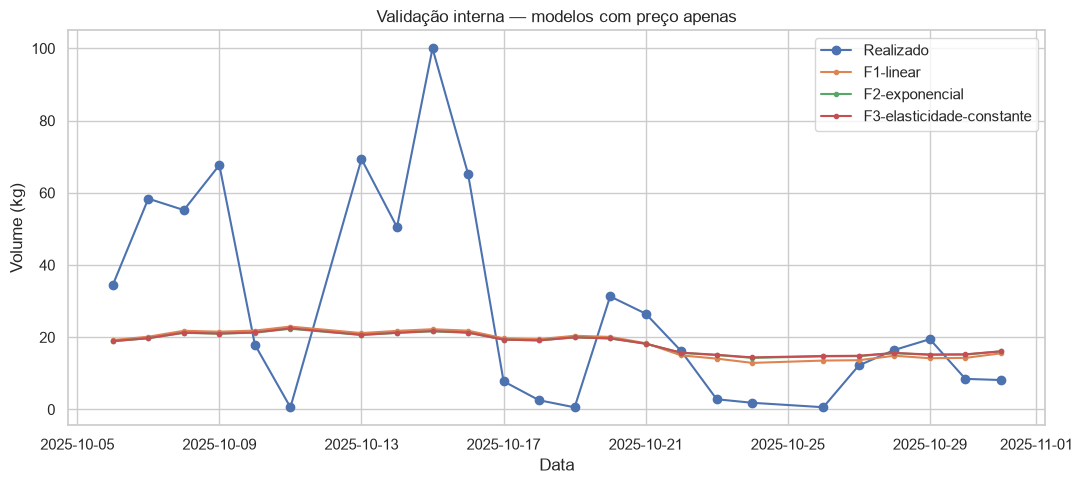

In [5]:
FORMAS = {
    'F1-linear': {'family': 'linear', 'calendar': 'none'},
    'F2-exponencial': {'family': 'exponential', 'calendar': 'none'},
    'F3-elasticidade-constante': {'family': 'power', 'calendar': 'none'},
}

linhas_forma = []
previsoes_forma = {}
for codigo, specification in FORMAS.items():
    linha, previsto, _, _ = avaliar_especificacao(codigo, specification)
    linhas_forma.append(linha)
    previsoes_forma[codigo] = previsto

ranking_forma = pd.DataFrame(linhas_forma).set_index('Código').sort_values('WMAPE')
ranking_forma.to_csv(TABLES_DIR / '02b_formas_preco_apenas.csv')

exibicao_forma = ranking_forma[[
    'Família', 'Parâmetros', 'Inclinação-base', 'p-valor inclinação-base',
    'R² na escala de ajuste', 'MAE', 'RMSE', 'MAPE', 'WMAPE', 'sMAPE',
    'Viés (%)', 'Previsão mínima',
]].copy()
for coluna in ['MAPE', 'WMAPE', 'sMAPE', 'Viés (%)']:
    exibicao_forma[coluna] *= 100
display(exibicao_forma.round(4))

figura, eixo = plt.subplots(figsize=(11, 5))
eixo.plot(validacao['data'], validacao['volume_kg'], marker='o', label='Realizado')
for codigo, previsto in previsoes_forma.items():
    eixo.plot(validacao['data'], previsto, marker='.', label=codigo)
eixo.set(
    title='Validação interna — modelos com preço apenas',
    xlabel='Data', ylabel='Volume (kg)',
)
eixo.legend()
figura.tight_layout()
figura.savefig(FIGURES_DIR / '02b_formas_preco_apenas.png', dpi=160, bbox_inches='tight')
plt.show()

**Resultado da primeira rodada.** A linear obteve WMAPE de `71,70%`; a exponencial,
`72,60%`; e a elasticidade constante, `72,62%`. A diferença inferior a um ponto percentual
não caracteriza vitória substantiva, e os três erros são altos. O preço sozinho não explica
a sazonalidade diária indicada pela Minerva. Em vez de fixar uma família por uma diferença
marginal, as três seguem para o mesmo desafio de calendário.

## 6. Segunda rodada: calendário sob as três formas

O enunciado afirma que início da semana, sexta-feira e sazonalidade diária alteram o volume.
Para formular os agrupamentos diretamente a partir dessas premissas, cinco estruturas são
definidas antes da comparação:

- `C0`: nenhum calendário;
- `C1`: dia útil versus fim de semana;
- `C2`: sete dias separados;
- `C3`: segunda–quinta, sexta e fim de semana;
- `C4`: segunda, terça–quinta, sexta e fim de semana.

Cada estrutura será aplicada às três famílias. A tabela identifica explicitamente família,
calendário, número de parâmetros e validade das previsões.

,Forma exibida,Estrutura exibida,Parâmetros,Válido para demanda,Previsões não positivas,MAE,RMSE,MAPE,WMAPE,sMAPE,BIC na escala de ajuste,AICc na escala de ajuste
Código,,,,,,,,,,,,
elasticidade-constante | C3-segqui-sex-fds,elasticidade-constante,C3-segqui-sex-fds,4,True,0,11.200,18.516,85.130,39.858,49.830,75.712,68.759
exponencial | C3-segqui-sex-fds,exponencial,C3-segqui-sex-fds,4,True,0,11.259,18.657,84.118,40.066,49.792,75.706,68.752
elasticidade-constante | C4-seg-terqui-sex-fds,elasticidade-constante,C4-seg-terqui-sex-fds,5,True,0,11.968,19.019,85.235,42.590,52.521,72.014,63.562
exponencial | C4-seg-terqui-sex-fds,exponencial,C4-seg-terqui-sex-fds,5,True,0,12.041,19.165,84.258,42.852,52.579,72.007,63.555
elasticidade-constante | C2-sete-dias,elasticidade-constante,C2-sete-dias,8,True,0,12.361,19.212,95.026,43.990,53.157,74.177,61.916
exponencial | C2-sete-dias,exponencial,C2-sete-dias,8,True,0,12.433,19.354,93.810,44.247,53.226,74.157,61.896
exponencial | C1-util-fds,exponencial,C1-util-fds,3,True,0,16.855,25.253,127.331,59.982,71.369,116.791,111.437
elasticidade-constante | C1-util-fds,elasticidade-constante,C1-util-fds,3,True,0,16.890,25.261,128.376,60.109,71.571,116.814,111.460
linear | C0-sem-calendario,linear,C0-sem-calendario,2,True,0,20.147,27.458,496.026,71.697,88.174,409.789,406.132


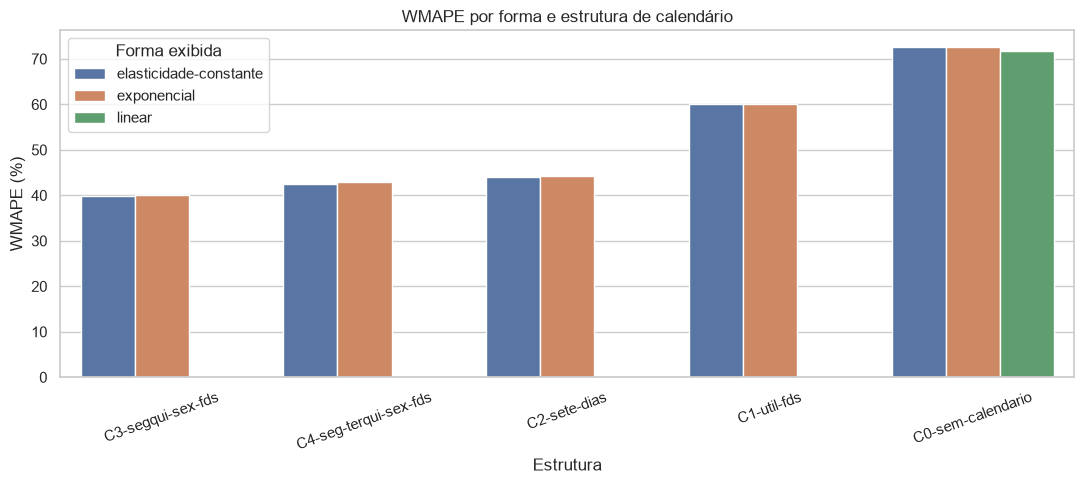

In [6]:
CALENDARIOS = {
    'C0-sem-calendario': 'none',
    'C1-util-fds': 'weekend',
    'C2-sete-dias': 'weekday',
    'C3-segqui-sex-fds': 'grouped',
    'C4-seg-terqui-sex-fds': 'grouped4',
}
FAMILIAS = {
    'linear': 'linear',
    'exponencial': 'exponential',
    'elasticidade-constante': 'power',
}

linhas_calendario = []
for rotulo_familia, family in FAMILIAS.items():
    for codigo_calendario, calendar in CALENDARIOS.items():
        codigo = f'{rotulo_familia} | {codigo_calendario}'
        specification = {'family': family, 'calendar': calendar}
        linha, _, _, _ = avaliar_especificacao(codigo, specification)
        linha['Forma exibida'] = rotulo_familia
        linha['Estrutura exibida'] = codigo_calendario
        linha['Válido para demanda'] = bool(
            linha['Previsões não positivas'] == 0
            and linha['Inclinação-base'] < 0
        )
        linhas_calendario.append(linha)

ranking_calendario = (
    pd.DataFrame(linhas_calendario)
    .set_index('Código')
    .sort_values(['Válido para demanda', 'WMAPE'], ascending=[False, True])
)
ranking_calendario.to_csv(TABLES_DIR / '02b_formas_e_calendarios.csv')

exibicao_calendario = ranking_calendario[[
    'Forma exibida', 'Estrutura exibida', 'Parâmetros', 'Válido para demanda',
    'Previsões não positivas', 'MAE', 'RMSE', 'MAPE', 'WMAPE', 'sMAPE',
    'BIC na escala de ajuste', 'AICc na escala de ajuste',
]].copy()
for coluna in ['MAPE', 'WMAPE', 'sMAPE']:
    exibicao_calendario[coluna] *= 100
display(exibicao_calendario.round(3))

validos = ranking_calendario.loc[ranking_calendario['Válido para demanda']].copy()
figura, eixo = plt.subplots(figsize=(11, 5))
grafico = validos.reset_index()
sns.barplot(
    data=grafico, x='Estrutura exibida', y=grafico['WMAPE'] * 100,
    hue='Forma exibida', ax=eixo,
)
eixo.set(
    title='WMAPE por forma e estrutura de calendário',
    xlabel='Estrutura', ylabel='WMAPE (%)',
)
eixo.tick_params(axis='x', rotation=20)
figura.tight_layout()
figura.savefig(FIGURES_DIR / '02b_formas_calendario.png', dpi=160, bbox_inches='tight')
plt.show()

**Resultado da rodada de calendário.** A combinação de elasticidade constante com `C3`
apresentou o menor WMAPE válido (`39,86%`), MAE de `11,20 kg` e RMSE de `18,52 kg`. A
exponencial com o mesmo calendário ficou praticamente empatada, com WMAPE de `40,07%`.
A linear passou a produzir volumes negativos em suas estruturas de calendário mais úteis e
não é apropriada para alimentar a otimização. Entre as duas curvas positivas quase
equivalentes, a potência é mantida porque teve erro ligeiramente menor, fornece elasticidade
diretamente e coincide com a forma \(A/P^B\) apresentada no documento da Minerva.

## 7. Terceira rodada: variáveis temporais incrementais

Com forma e calendário definidos, o processo *champion-challenger* passa a testar variáveis
adicionais citadas pelo enunciado. `inicio_mes` representa os dias 1 a 7. A tendência linear
representa mudanças graduais não explicadas pelo calendário. Cada acréscimo precisa melhorar
a validação temporal; p-valores e critérios de informação são evidências auxiliares.

In [7]:
INCREMENTAIS = {
    'M0-calendario': {
        'family': 'power', 'calendar': 'grouped',
        'start_month': False, 'trend': False,
    },
    'M1-inicio-mes': {
        'family': 'power', 'calendar': 'grouped',
        'start_month': True, 'trend': False,
    },
    'M2-tendencia': {
        'family': 'power', 'calendar': 'grouped',
        'start_month': False, 'trend': True,
    },
    'M3-inicio-mes-tendencia': {
        'family': 'power', 'calendar': 'grouped',
        'start_month': True, 'trend': True,
    },
}

linhas_incrementais = []
previsoes_incrementais = {}
for codigo, specification in INCREMENTAIS.items():
    linha, previsto, _, _ = avaliar_especificacao(codigo, specification)
    linhas_incrementais.append(linha)
    previsoes_incrementais[codigo] = previsto

ranking_incremental = (
    pd.DataFrame(linhas_incrementais).set_index('Código').sort_values('WMAPE')
)
ranking_incremental.to_csv(TABLES_DIR / '02b_variaveis_incrementais.csv')

exibicao_incremental = ranking_incremental[[
    'Início do mês', 'Tendência', 'Parâmetros', 'MAE', 'RMSE', 'MAPE',
    'WMAPE', 'sMAPE', 'Viés (%)', 'BIC na escala de ajuste',
    'AICc na escala de ajuste', 'Previsão mínima',
]].copy()
for coluna in ['MAPE', 'WMAPE', 'sMAPE', 'Viés (%)']:
    exibicao_incremental[coluna] *= 100
display(exibicao_incremental.round(3))

modelo_m1_hc3, _ = ajustar_modelo(ajuste, INCREMENTAIS['M1-inicio-mes'], robust=True)
print(f"p-valor HC3 de início do mês: {modelo_m1_hc3.pvalues['inicio_mes']:.4f}")

,Início do mês,Tendência,Parâmetros,MAE,RMSE,MAPE,WMAPE,sMAPE,Viés (%),BIC na escala de ajuste,AICc na escala de ajuste,Previsão mínima
Código,,,,,,,,,,,,
M1-inicio-mes,True,False,5,10.350,16.820,90.006,36.833,48.194,-25.352,76.679,68.227,1.194
M0-calendario,False,False,4,11.200,18.516,85.130,39.858,49.830,-29.933,75.712,68.759,1.191
M3-inicio-mes-tendencia,True,True,6,12.969,20.793,81.439,46.153,55.341,-39.164,79.392,69.551,1.083
M2-tendencia,False,True,5,13.953,22.296,78.921,49.655,58.623,-42.887,78.467,70.015,1.079


p-valor HC3 de início do mês: 0.1622


**Resultado incremental.** `M1` reduziu o WMAPE de `39,86%` para `36,83%`, o RMSE de
`18,52` para `16,82 kg` e o MAE de `11,20` para `10,35 kg`. A tendência piorou a previsão.
BIC favoreceu o modelo sem `inicio_mes`, enquanto AICc e a validação favoreceram levemente sua
inclusão. O coeficiente de início do mês não foi significativo no ajuste interno
(`p = 0,1622`), portanto sua permanência é uma decisão preditiva conforme o processo do livro,
não uma afirmação causal sobre o calendário.

## 8. Quarta rodada: elasticidade compartilhada ou por contexto

A especificação com elasticidade compartilhada permite níveis de demanda diferentes sem
supor respostas distintas ao preço. O challenger acrescenta as interações
`ln(preço) × sexta` e `ln(preço) × fim de semana`. A maior complexidade só será aceita se
melhorar a validação, mantiver demandas positivas e produzir inclinações economicamente
coerentes.

In [8]:
ELASTICIDADES = {
    'S0-compartilhada': {
        'family': 'power', 'calendar': 'grouped',
        'start_month': True, 'trend': False, 'interaction': False,
    },
    'S1-por-contexto': {
        'family': 'power', 'calendar': 'grouped',
        'start_month': True, 'trend': False, 'interaction': True,
    },
}

linhas_elasticidade = []
modelos_elasticidade = {}
for codigo, specification in ELASTICIDADES.items():
    linha, _, modelo, _ = avaliar_especificacao(codigo, specification)
    modelos_elasticidade[codigo] = modelo
    if specification['interaction']:
        elasticidade_base = float(modelo.params['ln_preco'])
        linha['Elasticidade segunda–quinta'] = elasticidade_base
        linha['Elasticidade sexta'] = float(
            elasticidade_base + modelo.params['ln_preco_x_Sexta']
        )
        linha['Elasticidade fim de semana'] = float(
            elasticidade_base + modelo.params['ln_preco_x_Fim_de_semana']
        )
    else:
        elasticidade_base = float(modelo.params['ln_preco'])
        linha['Elasticidade segunda–quinta'] = elasticidade_base
        linha['Elasticidade sexta'] = elasticidade_base
        linha['Elasticidade fim de semana'] = elasticidade_base
    linhas_elasticidade.append(linha)

ranking_elasticidade = (
    pd.DataFrame(linhas_elasticidade).set_index('Código').sort_values('WMAPE')
)

modelo_s1_hc3, _ = ajustar_modelo(
    ajuste, ELASTICIDADES['S1-por-contexto'], robust=True
)
nomes_s1 = list(modelo_s1_hc3.params.index)
restricoes = np.zeros((2, len(nomes_s1)))
restricoes[0, nomes_s1.index('ln_preco_x_Sexta')] = 1
restricoes[1, nomes_s1.index('ln_preco_x_Fim_de_semana')] = 1
teste_interacoes = modelo_s1_hc3.wald_test(restricoes, scalar=True)
ranking_elasticidade['p-valor conjunto interações'] = np.nan
ranking_elasticidade.loc[
    'S1-por-contexto', 'p-valor conjunto interações'
] = float(teste_interacoes.pvalue)
ranking_elasticidade.to_csv(TABLES_DIR / '02b_elasticidade_compartilhada_variada.csv')

exibicao_elasticidade = ranking_elasticidade[[
    'Parâmetros', 'Elasticidade segunda–quinta', 'Elasticidade sexta',
    'Elasticidade fim de semana', 'MAE', 'RMSE', 'MAPE', 'WMAPE',
    'sMAPE', 'BIC na escala de ajuste', 'AICc na escala de ajuste',
    'p-valor conjunto interações',
]].copy()
for coluna in ['MAPE', 'WMAPE', 'sMAPE']:
    exibicao_elasticidade[coluna] *= 100
display(exibicao_elasticidade.round(4))

,Parâmetros,Elasticidade segunda–quinta,Elasticidade sexta,Elasticidade fim de semana,MAE,RMSE,MAPE,WMAPE,sMAPE,BIC na escala de ajuste,AICc na escala de ajuste,p-valor conjunto interações
Código,,,,,,,,,,,,
S0-compartilhada,5,-9.2475,-9.2475,-9.2475,10.3499,16.8202,90.0057,36.8328,48.1937,76.6789,68.2270,NaN
S1-por-contexto,7,-7.2878,-12.2141,-12.2992,11.6792,18.8455,101.4289,41.5633,51.1398,83.9966,72.8834,0.8549


**Resultado das elasticidades.** `S0` obteve WMAPE de `36,83%`, contra `41,56%` de `S1`,
além de menor RMSE, BIC e AICc. O teste conjunto das interações apresentou `p = 0,8549`.
Embora as três inclinações de `S1` sejam negativas no ajuste interno, elas consomem dois
parâmetros adicionais sem melhorar a previsão. A elasticidade compartilhada é mantida por
desempenho, estabilidade e parcimônia.

## 9. Decisão antes do ajuste final

A seleção termina antes do holdout. O campeão combina a forma pedida pelo documento da
Minerva, calendário parcimonioso, início do mês e uma única elasticidade. Esta célula resume
as decisões para que o ajuste final não altere silenciosamente a especificação.

In [9]:
ESPECIFICACAO_CAMPEA = ELASTICIDADES['S0-compartilhada']
resumo_decisoes = pd.DataFrame([
    ('Forma funcional', 'Elasticidade constante', 'Melhor candidata positiva após calendário; forma A/P^B da Minerva'),
    ('Calendário', 'Segunda–quinta / sexta / fim de semana', 'Menor WMAPE válido e menos parâmetros que sete dias'),
    ('Início do mês', 'Incluído', 'Melhorou WMAPE, MAE e RMSE na validação'),
    ('Tendência', 'Excluída', 'Piorou a validação temporal'),
    ('Elasticidade', 'Compartilhada', 'S1 piorou previsão e complexidade'),
    ('Holdout', 'Ainda não acessado', 'Reservado para avaliação final'),
], columns=['Decisão', 'Escolha', 'Critério'])
display(resumo_decisoes)

,Decisão,Escolha,Critério
0,Forma funcional,Elasticidade constante,Melhor candidata positiva após calendário; for...
1,Calendário,Segunda–quinta / sexta / fim de semana,Menor WMAPE válido e menos parâmetros que sete...
2,Início do mês,Incluído,"Melhorou WMAPE, MAE e RMSE na validação"
3,Tendência,Excluída,Piorou a validação temporal
4,Elasticidade,Compartilhada,S1 piorou previsão e complexidade
5,Holdout,Ainda não acessado,Reservado para avaliação final


**Resultado da seleção.** A fórmula congelada para reestimação é

\[
\log(Q_t)=\alpha+\beta\log(P_t)+\gamma_1 I(\text{sexta})
+\gamma_2 I(\text{fim de semana})+\gamma_3 I(\text{início do mês})+\varepsilon_t.
\]

A categoria de referência é segunda a quinta. Nenhuma variável adicional será escolhida após
a leitura do holdout.

## 10. Ajuste final nas 76 observações

Conforme o processo do livro, o campeão é reestimado com todo o desenvolvimento depois de
encerrada a seleção. Erros-padrão HC3 são usados porque inferência convencional pode ser
sensível à heterocedasticidade. O fator de *smearing* é recalculado apenas nos 76 dias.

In [10]:
modelo_final_convencional, smearing_final = ajustar_modelo(
    dados, ESPECIFICACAO_CAMPEA, robust=False
)
modelo_final_hc3, _ = ajustar_modelo(
    dados, ESPECIFICACAO_CAMPEA, robust=True
)

intervalos = modelo_final_hc3.conf_int()
tabela_coeficientes = pd.DataFrame({
    'Coeficiente': modelo_final_hc3.params,
    'Erro padrão HC3': modelo_final_hc3.bse,
    'p-valor HC3': modelo_final_hc3.pvalues,
    'IC95 inferior': intervalos[0],
    'IC95 superior': intervalos[1],
})
tabela_coeficientes.to_csv(TABLES_DIR / '02b_coeficientes_finais.csv')
display(tabela_coeficientes.round(5))

efeitos_multiplicativos = pd.DataFrame({
    'Efeito': ['Sexta', 'Fim de semana', 'Início do mês'],
    'Variação de volume (%)': 100 * (
        np.exp([
            modelo_final_hc3.params['contexto_Sexta'],
            modelo_final_hc3.params['contexto_Fim_de_semana'],
            modelo_final_hc3.params['inicio_mes'],
        ]) - 1
    ),
})
display(efeitos_multiplicativos.round(2))
print(f'Fator de smearing: {smearing_final:.6f}')

,Coeficiente,Erro padrão HC3,p-valor HC3,IC95 inferior,IC95 superior
const,93.26977,19.53019,0.0000,54.99130,131.54823
ln_preco,-12.59445,2.73136,0.0000,-17.94780,-7.24109
contexto_Sexta,-1.34237,0.14631,0.0000,-1.62913,-1.05560
contexto_Fim_de_semana,-2.97317,0.29867,0.0000,-3.55856,-2.38778
inicio_mes,-0.15279,0.14461,0.2907,-0.43623,0.13064


,Efeito,Variação de volume (%)
0,Sexta,-73.88
1,Fim de semana,-94.89
2,Início do mês,-14.17


Fator de smearing: 1.120099


**Resultado do ajuste final.** A elasticidade compartilhada é `-12,59`, com intervalo HC3
de 95% entre `-17,95` e `-7,24` e `p < 0,001`. Mantido preço constante, sexta e fim de
semana apresentam níveis previstos substancialmente menores que segunda–quinta. O efeito de
início do mês é estimado em aproximadamente `-14,17%`, mas permanece impreciso
(`p = 0,2907`). Ele é conservado porque a regra de seleção foi definida pela validação, não
por significância isolada. O fator de retransformação é aproximadamente `1,1201`.

## 11. Diagnósticos de resíduos e influência

A curva será usada por um otimizador, portanto não basta informar erro médio. O teste de
Breusch–Pagan verifica variância não constante; Durbin–Watson e Ljung–Box examinam dependência
temporal; distância de Cook e *leave-one-out* mostram se poucos dias determinam a
elasticidade.

,Indicador,Resultado
0,Breusch–Pagan p-valor,0.04217
1,Durbin–Watson,1.83434
2,Ljung–Box p-valor (lag 5),0.96453
3,Cook > 4/n,5.00000
4,Alavancagem > 2p/n,7.00000
5,Elasticidade LOO mínima,-14.46027
6,Elasticidade LOO máxima,-11.43579
7,Maior deslocamento LOO,1.86582


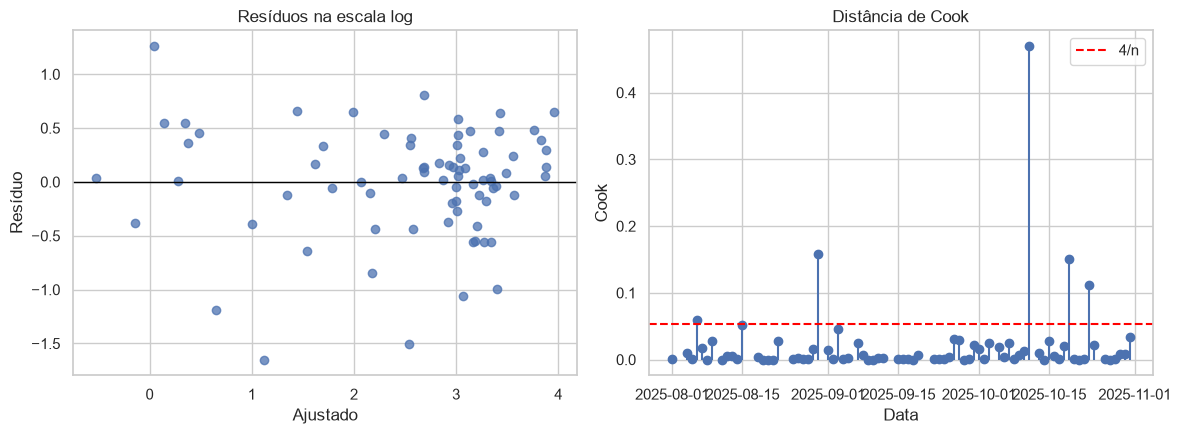

In [11]:
matriz_final = matriz_desenho(dados, ESPECIFICACAO_CAMPEA)
residuos = modelo_final_convencional.resid
bp_lm, bp_p, bp_f, bp_f_p = het_breuschpagan(residuos, matriz_final)
dw = float(durbin_watson(residuos))
ljung = acorr_ljungbox(residuos, lags=[5], return_df=True)

influencia = modelo_final_convencional.get_influence()
cooks = influencia.cooks_distance[0]
alavancagem = influencia.hat_matrix_diag
limite_cook = 4 / len(dados)
limite_alavancagem = 2 * matriz_final.shape[1] / len(dados)

elasticidades_loo = []
for indice in dados.index:
    base_loo = dados.drop(index=indice)
    modelo_loo, _ = ajustar_modelo(base_loo, ESPECIFICACAO_CAMPEA)
    elasticidades_loo.append(float(modelo_loo.params['ln_preco']))

diagnosticos = pd.DataFrame({
    'Indicador': [
        'Breusch–Pagan p-valor', 'Durbin–Watson', 'Ljung–Box p-valor (lag 5)',
        'Cook > 4/n', 'Alavancagem > 2p/n', 'Elasticidade LOO mínima',
        'Elasticidade LOO máxima', 'Maior deslocamento LOO',
    ],
    'Resultado': [
        bp_p, dw, float(ljung.loc[5, 'lb_pvalue']),
        int(np.sum(cooks > limite_cook)),
        int(np.sum(alavancagem > limite_alavancagem)),
        min(elasticidades_loo), max(elasticidades_loo),
        float(np.max(np.abs(np.asarray(elasticidades_loo) - modelo_final_hc3.params['ln_preco']))),
    ],
})
diagnosticos.to_csv(TABLES_DIR / '02b_diagnosticos.csv', index=False)
display(diagnosticos.round(5))

figura, eixos = plt.subplots(1, 2, figsize=(12, 4.5))
eixos[0].scatter(modelo_final_convencional.fittedvalues, residuos, alpha=0.75)
eixos[0].axhline(0, color='black', linewidth=1)
eixos[0].set(title='Resíduos na escala log', xlabel='Ajustado', ylabel='Resíduo')
eixos[1].stem(dados['data'], cooks, markerfmt='o', basefmt=' ')
eixos[1].axhline(limite_cook, color='red', linestyle='--', label='4/n')
eixos[1].set(title='Distância de Cook', xlabel='Data', ylabel='Cook')
eixos[1].legend()
figura.tight_layout()
figura.savefig(FIGURES_DIR / '02b_diagnosticos_influencia.png', dpi=160, bbox_inches='tight')
plt.show()

**Resultado dos diagnósticos.** O Breusch–Pagan apresenta `p = 0,0422`, sustentando o uso de
HC3. Durbin–Watson é `1,83` e o Ljung–Box em cinco defasagens apresenta `p = 0,9645`, sem
evidência de autocorrelação residual nesse horizonte. Cinco observações superam `4/n` para
Cook e sete superam a referência de alavancagem. Retirar um dia por vez desloca a
elasticidade entre `-14,46` e `-11,44`; o sinal é estável, mas a magnitude ainda depende da
amostra curta.

## 12. Colinearidade com preço e limite causal

A seção 4.4 de Phillips recomenda investigar se variáveis explicativas também predizem o
preço. Regressar preço sobre calendário e início do mês não prova exogeneidade, mas revela se
esses controles estão mecanicamente associados à política histórica de preços. Endogeneidade
por demanda antecipada ou variáveis omitidas continuará possível mesmo com resultado nulo.

In [12]:
matriz_preco = matriz_final.drop(columns=['ln_preco'])
modelo_preco = sm.OLS(dados['preco_kg'], matriz_preco).fit(cov_type='HC3')
tabela_preco = pd.DataFrame({
    'Coeficiente': modelo_preco.params,
    'p-valor HC3': modelo_preco.pvalues,
})
display(tabela_preco.round(5))
print(f'R² da regressão de preço: {modelo_preco.rsquared:.5f}')
print(f'p-valor conjunto: {modelo_preco.f_pvalue:.5f}')

,Coeficiente,p-valor HC3
const,1278.90595,0.00000
contexto_Sexta,-2.29805,0.86286
contexto_Fim_de_semana,-8.26615,0.60341
inicio_mes,-10.60547,0.26021


R² da regressão de preço: 0.01750
p-valor conjunto: 0.67079


**Resultado da verificação causal.** Calendário e início do mês explicam apenas `1,75%` da
variação histórica de preço e o teste conjunto apresenta `p = 0,6708`. Não há evidência de
colinearidade relevante entre esses controles e preço. Isso não elimina endogeneidade:
promoções, estoque, negociação comercial e demanda antecipada não estão observados. A curva
continua sendo preditiva e deve ser usada localmente, com análise de sensibilidade.

## 13. Incerteza e suporte para a otimização

O documento da Minerva alerta que previsões pontuais podem ser limitadoras. Um bootstrap por
semanas preserva parte da dependência dentro de cada bloco e mede a estabilidade da
elasticidade. Razões entre volume real e previsto na validação geram cenários conservador e
otimista. As curvas também ficam restritas ao suporte de preço de cada contexto.

,Indicador,Resultado
0,"Elasticidade bootstrap 2,5%",-16.6539
1,Elasticidade bootstrap mediana,-12.6489
2,"Elasticidade bootstrap 97,5%",-7.9100
3,Proporção não negativa,0.0000
4,Multiplicador conservador,0.5169
5,Multiplicador central,1.0000
6,Multiplicador otimista,1.5841


,n,preco_min,preco_max
contexto,,,
Segunda_a_Quinta,52,1201.63,1352.42
Sexta,14,1208.37,1365.49
Fim_de_semana,10,1188.86,1354.19


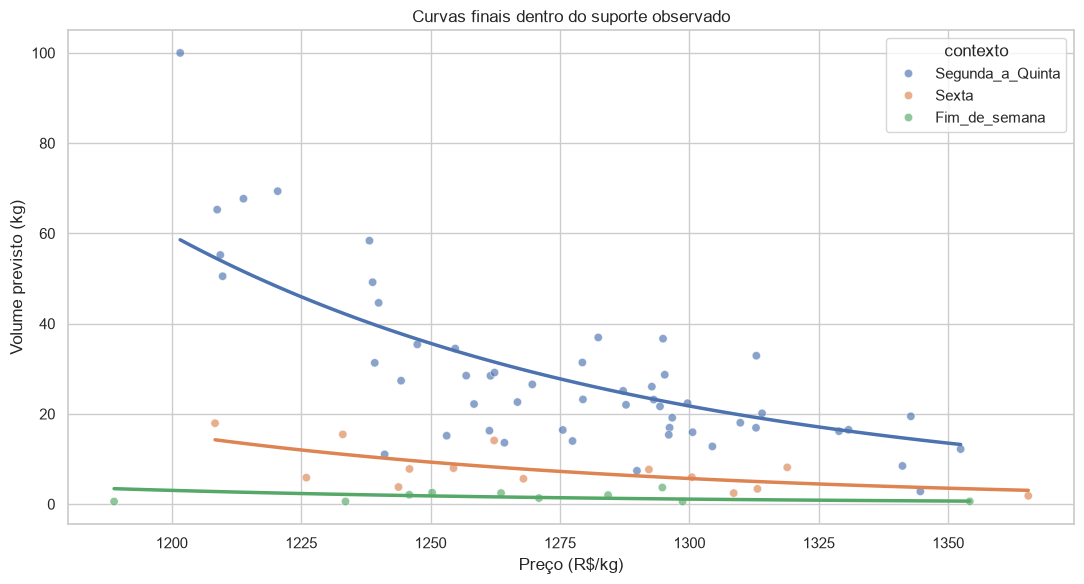

In [13]:
gerador = np.random.default_rng(SEMENTE)
semanas = dados['inicio_semana'].drop_duplicates().to_numpy()
elasticidades_bootstrap = []
for _ in range(1000):
    blocos = []
    for numero, semana in enumerate(
        gerador.choice(semanas, size=len(semanas), replace=True)
    ):
        bloco = dados.loc[dados['inicio_semana'] == semana].copy()
        bloco.index = np.arange(numero * 100, numero * 100 + len(bloco))
        blocos.append(bloco)
    amostra = pd.concat(blocos)
    modelo_bootstrap, _ = ajustar_modelo(amostra, ESPECIFICACAO_CAMPEA)
    elasticidades_bootstrap.append(float(modelo_bootstrap.params['ln_preco']))

quantis_elasticidade = np.quantile(elasticidades_bootstrap, [0.025, 0.5, 0.975])

_, previsao_validacao_campea, _, _ = avaliar_especificacao(
    'S0-compartilhada', ESPECIFICACAO_CAMPEA
)
razao_validacao = validacao['volume_kg'].to_numpy() / previsao_validacao_campea
multiplicadores = {
    'conservador': float(np.quantile(razao_validacao, 0.20)),
    'central': 1.0,
    'otimista': float(np.quantile(razao_validacao, 0.80)),
}

contexto_dados = dados['dia_semana'].map(MAPAS_CONTEXTO['grouped'])
suporte = (
    dados.assign(contexto=contexto_dados)
    .groupby('contexto')
    .agg(n=('preco_kg', 'size'), preco_min=('preco_kg', 'min'), preco_max=('preco_kg', 'max'))
    .reindex(ORDEM_CONTEXTO['grouped'])
)

resumo_incerteza = pd.DataFrame({
    'Indicador': [
        'Elasticidade bootstrap 2,5%', 'Elasticidade bootstrap mediana',
        'Elasticidade bootstrap 97,5%', 'Proporção não negativa',
        'Multiplicador conservador', 'Multiplicador central',
        'Multiplicador otimista',
    ],
    'Resultado': [
        quantis_elasticidade[0], quantis_elasticidade[1], quantis_elasticidade[2],
        float(np.mean(np.asarray(elasticidades_bootstrap) >= 0)),
        multiplicadores['conservador'], multiplicadores['central'],
        multiplicadores['otimista'],
    ],
})
resumo_incerteza.to_csv(TABLES_DIR / '02b_incerteza.csv', index=False)
suporte.to_csv(TABLES_DIR / '02b_suporte_preco.csv')
display(resumo_incerteza.round(4))
display(suporte.round(2))

dia_representativo = {
    'Segunda_a_Quinta': 'Segunda', 'Sexta': 'Sexta', 'Fim_de_semana': 'Sábado'
}
linhas_curva = []
for contexto, linha in suporte.iterrows():
    grade = np.linspace(linha['preco_min'], linha['preco_max'], 100)
    base_curva = pd.DataFrame({
        'preco_kg': grade,
        'dia_semana': dia_representativo[contexto],
        'inicio_mes': 0,
        'indice_tempo': 0,
    })
    previsto = prever_modelo(
        modelo_final_convencional, smearing_final, base_curva, ESPECIFICACAO_CAMPEA
    )
    linhas_curva.extend({
        'contexto': contexto, 'preco_kg': preco, 'volume_previsto_kg': volume
    } for preco, volume in zip(grade, previsto))
curvas = pd.DataFrame(linhas_curva)
ordem_contextos = ['Segunda_a_Quinta', 'Sexta', 'Fim_de_semana']
paleta_contextos = {
    'Segunda_a_Quinta': '#4c72b0',
    'Sexta': '#dd8452',
    'Fim_de_semana': '#55a868',
}

figura, eixo = plt.subplots(figsize=(11, 6))
sns.scatterplot(
    data=dados.assign(contexto=contexto_dados), x='preco_kg', y='volume_kg',
    hue='contexto', hue_order=ordem_contextos, palette=paleta_contextos,
    alpha=0.65, ax=eixo,
)
sns.lineplot(
    data=curvas, x='preco_kg', y='volume_previsto_kg',
    hue='contexto', hue_order=ordem_contextos, palette=paleta_contextos,
    linewidth=2.5, legend=False, ax=eixo,
)
eixo.set(
    title='Curvas finais dentro do suporte observado',
    xlabel='Preço (R$/kg)', ylabel='Volume previsto (kg)',
)
figura.tight_layout()
figura.savefig(FIGURES_DIR / '02b_curvas_suporte.png', dpi=160, bbox_inches='tight')
plt.show()

**Resultado da incerteza.** O bootstrap semanal produz intervalo de 95% para a elasticidade
entre `-16,65` e `-7,91`, sem réplicas não negativas. A magnitude é incerta, mas o sinal
negativo é estável. Os multiplicadores de volume são aproximadamente `0,517`, `1,000` e
`1,584`. O fim de semana possui somente dez observações; suas previsões exigem cautela. A
otimização não deve extrapolar os limites de preço mostrados para cada contexto.

## 14. Congelamento antes do holdout

Coeficientes, transformação, calendário, suporte e critérios de seleção serão serializados
antes da primeira leitura dos dez dias oficiais. Um hash do núcleo do modelo permite provar
que a avaliação posterior não alterou sua função de demanda.

In [14]:
suporte_json = {
    contexto: {
        'min': float(linha['preco_min']),
        'max': float(linha['preco_max']),
        'n': int(linha['n']),
    }
    for contexto, linha in suporte.iterrows()
}

artifact = {
    'artifact_version': 1,
    'model_id': 'book-method-power-grouped-start-month-s0',
    'family': 'power',
    'formula': (
        'ln(volume_kg) ~ ln(preco_kg) + I(sexta) + '
        'I(fim_de_semana) + I(dia_do_mes <= 7)'
    ),
    'calendar': {
        'baseline': 'Segunda_a_Quinta',
        'contexts': ORDEM_CONTEXTO['grouped'],
        'mapping': MAPAS_CONTEXTO['grouped'],
        'start_month_definition': 'dia do mês entre 1 e 7',
    },
    'feature_order': list(modelo_final_convencional.params.index),
    'coefficients': {
        nome: float(valor) for nome, valor in modelo_final_convencional.params.items()
    },
    'smearing_factor': float(smearing_final),
    'price_support': suporte_json,
    'training': {
        'rows': len(dados),
        'start': dados['data'].min().date().isoformat(),
        'end': dados['data'].max().date().isoformat(),
        'data_file': str(DATA_PATH.relative_to(ROOT)),
        'data_sha256': arquivo_sha256(DATA_PATH),
    },
    'selection': {
        'internal_fit_rows': len(ajuste),
        'internal_validation_rows': len(validacao),
        'validation_start': validacao['data'].min().date().isoformat(),
        'validation_end': validacao['data'].max().date().isoformat(),
        'primary_metric': 'WMAPE',
        'champion_metrics': calcular_metricas(
            validacao['volume_kg'], previsao_validacao_campea
        ),
    },
    'inference': {
        'covariance': 'HC3',
        'elasticity': float(modelo_final_hc3.params['ln_preco']),
        'elasticity_ci95': [
            float(intervalos.loc['ln_preco', 0]),
            float(intervalos.loc['ln_preco', 1]),
        ],
    },
    'observational_warning': (
        'Curva preditiva observacional. Variáveis omitidas e demanda antecipada '
        'podem tornar o coeficiente de preço não causal.'
    ),
    'holdout_evaluation': None,
}

def nucleo_modelo(objeto):
    chaves = [
        'model_id', 'family', 'formula', 'calendar', 'feature_order',
        'coefficients', 'smearing_factor', 'price_support',
    ]
    return {chave: objeto[chave] for chave in chaves}

def hash_nucleo(objeto):
    serializado = json.dumps(
        nucleo_modelo(objeto), ensure_ascii=False, sort_keys=True,
        separators=(',', ':'),
    ).encode('utf-8')
    return hashlib.sha256(serializado).hexdigest()

artifact['model_core_sha256'] = hash_nucleo(artifact)
frozen_core_hash = artifact['model_core_sha256']
salvar_json(artifact, CHAMPION_PATH)

uncertainty_artifact = {
    'artifact_version': 1,
    'model_core_sha256': frozen_core_hash,
    'bootstrap_seed': SEMENTE,
    'bootstrap_replications': 1000,
    'bootstrap_block': 'inicio_semana',
    'elasticity_quantiles': {
        'q025': float(quantis_elasticidade[0]),
        'q500': float(quantis_elasticidade[1]),
        'q975': float(quantis_elasticidade[2]),
    },
    'scenario_multipliers': multiplicadores,
}
salvar_json(uncertainty_artifact, UNCERTAINTY_PATH)

selection_summary = {
    'method': 'Phillips 4.2-4.3 adapted to official Minerva holdout',
    'functional_round': json.loads(ranking_forma.reset_index().to_json(orient='records')),
    'calendar_round': json.loads(ranking_calendario.reset_index().to_json(orient='records')),
    'incremental_round': json.loads(ranking_incremental.reset_index().to_json(orient='records')),
    'elasticity_round': json.loads(ranking_elasticidade.reset_index().to_json(orient='records')),
    'champion': artifact['model_id'],
    'model_core_sha256': frozen_core_hash,
}
salvar_json(selection_summary, SELECTION_PATH)

print(f'Modelo congelado: {CHAMPION_PATH}')
print(f'Hash do núcleo: {frozen_core_hash}')

Modelo congelado: /Users/ngodeny/Documents/mestrado/202602-resolucao_problemas/models/demand_curve_champion_livro.json
Hash do núcleo: 0b24565fee5671e87741e4975cc9090fac5d17434c50f0a0e6f881d670c6106f


**Resultado do congelamento.** O artefato campeão, o resumo de seleção e o artefato de
incerteza foram gravados antes do holdout. O hash identifica exatamente a função que será
avaliada e posteriormente entregue ao notebook de otimização.

## 15. Avaliação única no holdout oficial

Somente agora são carregados os dez dias de novembro definidos pela Minerva. O volume é
previsto nos preços efetivamente realizados, permitindo medir generalização. Essa avaliação
não selecionará novas variáveis, não recalibrará coeficientes e não modificará o fator de
*smearing*.

,data,volume_real_kg,preco_kg,numero_dia_semana,dia_semana,inicio_mes,indice_tempo,inicio_semana,contexto,preco_dentro_suporte,volume_previsto_kg,erro_kg,erro_absoluto_kg
0,2025-11-03,29.907,1343.797,0,Segunda,1,76,2025-11-03,Segunda_a_Quinta,True,12.297,-17.609,17.609
1,2025-11-04,9.467,1294.317,1,Terça,1,77,2025-11-03,Segunda_a_Quinta,True,19.725,10.258,10.258
2,2025-11-05,16.435,1311.529,2,Quarta,1,78,2025-11-03,Segunda_a_Quinta,True,16.702,0.267,0.267
3,2025-11-06,17.256,1334.935,3,Quinta,1,79,2025-11-03,Segunda_a_Quinta,True,13.366,-3.890,3.890
4,2025-11-07,1.176,1327.982,4,Sexta,1,80,2025-11-03,Sexta,True,3.729,2.553,2.553
5,2025-11-10,18.186,1334.797,0,Segunda,0,81,2025-11-10,Segunda_a_Quinta,True,15.593,-2.593,2.593
6,2025-11-11,27.573,1302.994,1,Terça,0,82,2025-11-10,Segunda_a_Quinta,True,21.126,-6.446,6.446
7,2025-11-12,21.367,1311.074,2,Quarta,0,83,2025-11-10,Segunda_a_Quinta,True,19.544,-1.823,1.823
8,2025-11-13,32.469,1318.274,3,Quinta,0,84,2025-11-10,Segunda_a_Quinta,True,18.241,-14.228,14.228
9,2025-11-14,9.793,1282.923,4,Sexta,0,85,2025-11-10,Sexta,True,6.710,-3.083,3.083


,MAE,RMSE,MAPE,WMAPE,sMAPE,Viés (%),Previsão mínima,Previsões não positivas
0,6.275,8.37,52.995,34.172,42.905,-19.929,3.729,0


,volume_real_kg,volume_previsto_kg,erro_kg
inicio_semana,,,
2025-11-03,74.241,65.819,-8.422
2025-11-10,109.388,81.215,-28.173


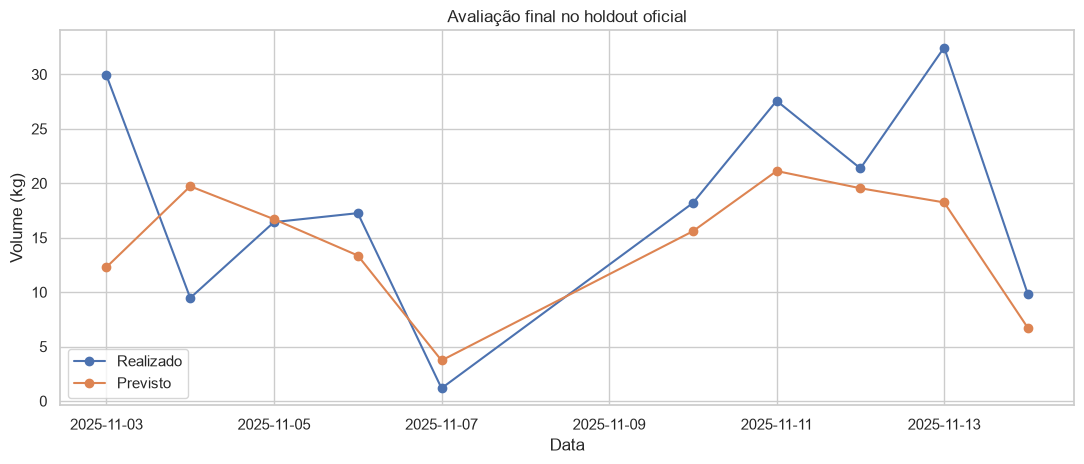

In [15]:
holdout_raw = pd.read_csv(HOLDOUT_PATH, parse_dates=['Data']).sort_values('Data')
holdout = pd.DataFrame({
    'data': holdout_raw['Data'],
    'volume_real_kg': holdout_raw['Volume Realizado (kg)'].astype(float),
    'preco_kg': (
        holdout_raw['Receita Realizada (R$)']
        / holdout_raw['Volume Realizado (kg)']
    ),
}).reset_index(drop=True)
holdout['numero_dia_semana'] = holdout['data'].dt.dayofweek
holdout['dia_semana'] = holdout['numero_dia_semana'].map(dict(enumerate(ORDEM_DIAS)))
holdout['inicio_mes'] = (holdout['data'].dt.day <= 7).astype(int)
holdout['indice_tempo'] = np.arange(len(dados), len(dados) + len(holdout))
holdout['inicio_semana'] = (
    holdout['data']
    - pd.to_timedelta(holdout['numero_dia_semana'], unit='D')
)
holdout['contexto'] = holdout['dia_semana'].map(MAPAS_CONTEXTO['grouped'])

dentro_suporte = []
for _, linha in holdout.iterrows():
    limites = suporte_json[linha['contexto']]
    dentro_suporte.append(limites['min'] <= linha['preco_kg'] <= limites['max'])
holdout['preco_dentro_suporte'] = dentro_suporte
if not holdout['preco_dentro_suporte'].all():
    raise ValueError('O holdout contém preço fora do suporte do desenvolvimento.')

holdout['volume_previsto_kg'] = prever_modelo(
    modelo_final_convencional, smearing_final, holdout, ESPECIFICACAO_CAMPEA
)
holdout['erro_kg'] = holdout['volume_previsto_kg'] - holdout['volume_real_kg']
holdout['erro_absoluto_kg'] = holdout['erro_kg'].abs()
metricas_holdout = calcular_metricas(
    holdout['volume_real_kg'], holdout['volume_previsto_kg']
)

semanal_holdout = holdout.groupby('inicio_semana')[[
    'volume_real_kg', 'volume_previsto_kg'
]].sum()
semanal_holdout['erro_kg'] = (
    semanal_holdout['volume_previsto_kg'] - semanal_holdout['volume_real_kg']
)

holdout.to_csv(HOLDOUT_PREDICTIONS_PATH, index=False)
holdout.to_csv(TABLES_DIR / '02b_previsoes_holdout.csv', index=False)
exibicao_holdout = holdout.copy()
colunas_numericas = exibicao_holdout.select_dtypes(include='number').columns
exibicao_holdout[colunas_numericas] = exibicao_holdout[colunas_numericas].round(3)
display(exibicao_holdout)

exibicao_metricas_holdout = pd.DataFrame([metricas_holdout])
for coluna in ['MAPE', 'WMAPE', 'sMAPE', 'Viés (%)']:
    exibicao_metricas_holdout[coluna] *= 100
display(exibicao_metricas_holdout.round(3))
display(semanal_holdout.round(3))

figura, eixo = plt.subplots(figsize=(11, 4.8))
eixo.plot(holdout['data'], holdout['volume_real_kg'], marker='o', label='Realizado')
eixo.plot(holdout['data'], holdout['volume_previsto_kg'], marker='o', label='Previsto')
eixo.set(
    title='Avaliação final no holdout oficial',
    xlabel='Data', ylabel='Volume (kg)',
)
eixo.legend()
figura.tight_layout()
figura.savefig(FIGURES_DIR / '02b_holdout.png', dpi=160, bbox_inches='tight')
plt.show()

**Resultado do holdout.** Todos os preços estão dentro do suporte e os dez dias são úteis,
portanto o holdout não avalia fim de semana. O modelo obteve WMAPE de `34,17%`, MAE de
`6,27 kg`, RMSE de `8,37 kg`, MAPE de `52,99%` e sMAPE de `42,91%`. Previu `147,03 kg`
diante de `183,63 kg` realizados, viés acumulado de `-19,93%`. O desempenho é melhor que na
validação interna, mas a subestimação agregada deve compor os cenários da otimização; nenhum
parâmetro é alterado após esse resultado.

## 16. Produto final para a otimização

O artefato recebe apenas o registro da avaliação, preservando o hash do núcleo. Também é
gerada uma tabela preço-volume por dia da semana, dentro do suporte observado, para os
cenários conservador, central e otimista. A tabela é produto do notebook; nenhum script de
produção é criado nesta fase.

In [16]:
artifact_final = carregar_json(CHAMPION_PATH)
if hash_nucleo(artifact_final) != frozen_core_hash:
    raise ValueError('O núcleo do modelo mudou antes do registro do holdout.')

artifact_final['holdout_evaluation'] = {
    'rows': len(holdout),
    'start': holdout['data'].min().date().isoformat(),
    'end': holdout['data'].max().date().isoformat(),
    'contains_weekend': bool(
        holdout['dia_semana'].isin(['Sábado', 'Domingo']).any()
    ),
    'metrics': metricas_holdout,
    'predictions_file': str(HOLDOUT_PREDICTIONS_PATH.relative_to(ROOT)),
    'frozen_model_core_sha256': frozen_core_hash,
}
salvar_json(artifact_final, CHAMPION_PATH)
if hash_nucleo(carregar_json(CHAMPION_PATH)) != frozen_core_hash:
    raise ValueError('O núcleo do modelo mudou depois do holdout.')

linhas_cenarios = []
for dia in ORDEM_DIAS:
    contexto = MAPAS_CONTEXTO['grouped'][dia]
    limites = suporte_json[contexto]
    for inicio_mes in [0, 1]:
        grade = np.linspace(limites['min'], limites['max'], 31)
        base_grade = pd.DataFrame({
            'preco_kg': grade,
            'dia_semana': dia,
            'inicio_mes': inicio_mes,
            'indice_tempo': 0,
        })
        central = prever_modelo(
            modelo_final_convencional, smearing_final,
            base_grade, ESPECIFICACAO_CAMPEA,
        )
        for preco, volume in zip(grade, central):
            linhas_cenarios.append({
                'dia_semana': dia,
                'contexto': contexto,
                'inicio_mes': inicio_mes,
                'preco_kg': float(preco),
                'volume_conservador_kg': float(volume * multiplicadores['conservador']),
                'volume_central_kg': float(volume),
                'volume_otimista_kg': float(volume * multiplicadores['otimista']),
            })
tabela_cenarios = pd.DataFrame(linhas_cenarios)
tabela_cenarios.to_csv(
    TABLES_DIR / '02b_tabela_preco_volume_cenarios.csv', index=False
)

entregaveis = [
    CHAMPION_PATH,
    UNCERTAINTY_PATH,
    SELECTION_PATH,
    HOLDOUT_PREDICTIONS_PATH,
    TABLES_DIR / '02b_formas_preco_apenas.csv',
    TABLES_DIR / '02b_formas_e_calendarios.csv',
    TABLES_DIR / '02b_variaveis_incrementais.csv',
    TABLES_DIR / '02b_elasticidade_compartilhada_variada.csv',
    TABLES_DIR / '02b_tabela_preco_volume_cenarios.csv',
    FIGURES_DIR / '02b_formas_preco_apenas.png',
    FIGURES_DIR / '02b_formas_calendario.png',
    FIGURES_DIR / '02b_diagnosticos_influencia.png',
    FIGURES_DIR / '02b_curvas_suporte.png',
    FIGURES_DIR / '02b_holdout.png',
]
faltantes = [str(path) for path in entregaveis if not path.exists()]
if faltantes:
    raise FileNotFoundError(f'Entregáveis ausentes: {faltantes}')

print('Notebook concluído com o núcleo preservado.')
print(f'Artefato campeão: {CHAMPION_PATH}')
print(f'Tabela de cenários: {TABLES_DIR / "02b_tabela_preco_volume_cenarios.csv"}')
print(f'Hash final: {frozen_core_hash}')

Notebook concluído com o núcleo preservado.
Artefato campeão: /Users/ngodeny/Documents/mestrado/202602-resolucao_problemas/models/demand_curve_champion_livro.json
Tabela de cenários: /Users/ngodeny/Documents/mestrado/202602-resolucao_problemas/reports/tables/02b_tabela_preco_volume_cenarios.csv
Hash final: 0b24565fee5671e87741e4975cc9090fac5d17434c50f0a0e6f881d670c6106f


**Resultado dos produtos.** O hash permanece inalterado após o holdout. O notebook entrega
um modelo reproduzível, métricas de seleção, incerteza, previsões oficiais e uma grade de
preço-volume pronta para formular o problema de otimização. A grade bloqueia extrapolação
além do histórico e diferencia início do mês dos demais dias.

## 17. Conclusões

1. Preço isolado é insuficiente: as três formas apresentaram WMAPE superior a 70%.
2. Depois de controlar calendário, potência e exponencial ficaram próximas; potência foi
   escolhida por desempenho ligeiramente melhor, demanda positiva, elasticidade direta e
   alinhamento à curva indicada pela Minerva.
3. A estrutura segunda–quinta, sexta e fim de semana superou tanto o indicador simples de
   fim de semana quanto sete dias separados.
4. Início do mês melhorou a validação, mas seu coeficiente é impreciso; deve ser tratado como
   componente preditivo, não efeito causal estabelecido.
5. Elasticidades por contexto pioraram a validação e foram rejeitadas. A curva final possui
   elasticidade compartilhada de aproximadamente `-12,59`.
6. O holdout oficial apresentou WMAPE de `34,17%` e subestimação acumulada de `19,93%`.
7. A curva é observacional, local ao suporte histórico e deve entrar na otimização junto com
   cenários de incerteza, nunca como resposta causal conhecida sem erro.

## 18. Referências

- Phillips, R. L. *Pricing and Revenue Optimization*. 2ª ed. Stanford University Press,
  2021. Seções 4.2 a 4.4.
- Minerva Foods; Unifesp; ITA. *Otimização de precificação aplicado ao segmento de carnes in
  natura — Desafio Minerva-Unifesp-ITA*, 2026.
- Duan, N. “Smearing Estimate: A Nonparametric Retransformation Method.” *Journal of the
  American Statistical Association*, 1983.